In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Data Loading and Understanding

The assignment requires the Excel dataset to be loaded using Pandas and inspected through its rows, shape, columns, data types, and basic statistics.

**Dataset file expected:** `WA_Fn-UseC_-Telco-Customer-Churn.xlsx`


In [5]:
# Load the dataset
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(file_path)

print("First 5 rows:")
display(df.head())

print("\nDataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nBasic statistics:")
display(df.describe(include="all").T)


First 5 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes



Dataset shape: (7043, 21)

Column names:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']

Data types:


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object



Basic statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,3186-AJIEK,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Identify the target variable
target = "Churn"

print("Target variable:", target)
print("\nTarget distribution:")
display(df[target].value_counts(dropna=False))

print("\nTarget distribution (%):")
display((df[target].value_counts(normalize=True, dropna=False) * 100).round(2))


Target variable: Churn

Target distribution:


,count
Churn,
No,5174
Yes,1869



Target distribution (%):


,proportion
Churn,
No,73.46
Yes,26.54


### Important columns

- **customerID:** Unique identifier for a customer.
- **gender:** Customer's gender.
- **SeniorCitizen:** Indicates whether the customer is a senior citizen.
- **Partner:** Whether the customer has a partner.
- **Dependents:** Whether the customer has dependents.
- **tenure:** Number of months the customer has stayed with the company.
- **PhoneService / InternetService:** Services used by the customer.
- **Contract:** Customer's contract type.
- **PaymentMethod:** Method used for payment.
- **MonthlyCharges:** Customer's monthly charge.
- **TotalCharges:** Total amount charged to the customer.
- **Churn:** Target variable showing whether the customer left the company (`Yes`) or stayed (`No`).


## 2. Data Preprocessing

In [7]:
# Check missing values
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])

# Check duplicate records
print("Number of duplicate rows:", df.duplicated().sum())

# Check unique values in important columns
print("\nUnique values in TotalCharges:")
print(df["TotalCharges"].head(10).tolist())


,0


Number of duplicate rows: 0

Unique values in TotalCharges:
['29.85', '1889.5', '108.15', '1840.75', '151.65', '820.5', '1949.4', '301.9', '3046.05', '3487.95']


In [8]:
# Convert TotalCharges to numeric.
# Some versions of this dataset contain blank strings in this column.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print("Missing values after converting TotalCharges:")
display(df.isnull().sum()[df.isnull().sum() > 0])

# Remove exact duplicate rows if any
before = len(df)
df = df.drop_duplicates().copy()
after = len(df)

print(f"Duplicate rows removed: {before - after}")

# Remove rows with missing target
df = df.dropna(subset=["Churn"]).copy()

print("Final dataset shape after basic cleaning:", df.shape)


Missing values after converting TotalCharges:


,0
TotalCharges,11


Duplicate rows removed: 0
Final dataset shape after basic cleaning: (7043, 21)


## 3. Exploratory Data Analysis

The following visualizations examine churn distribution and relationships between churn and important customer characteristics.


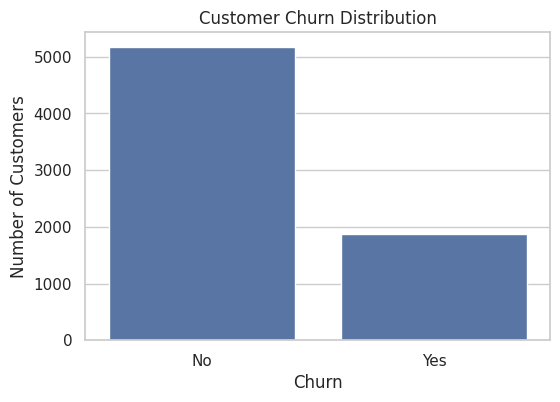

In [9]:
# Churn distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()


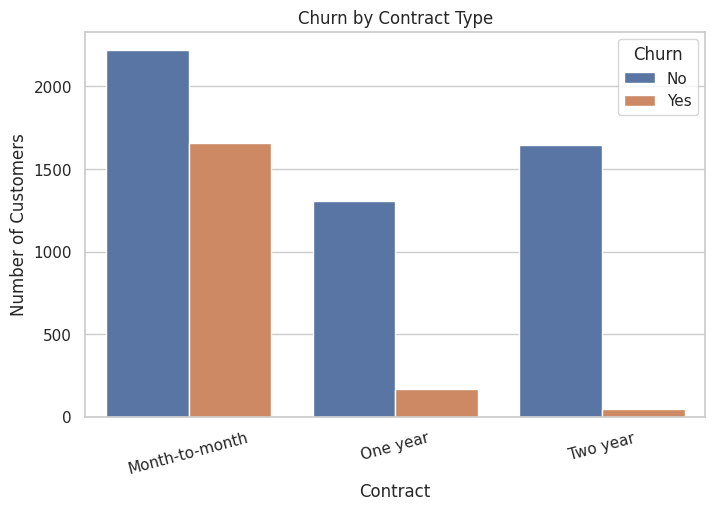

In [10]:
# Churn by contract type
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Churn by Contract Type")
plt.xlabel("Contract")
plt.ylabel("Number of Customers")
plt.xticks(rotation=15)
plt.show()


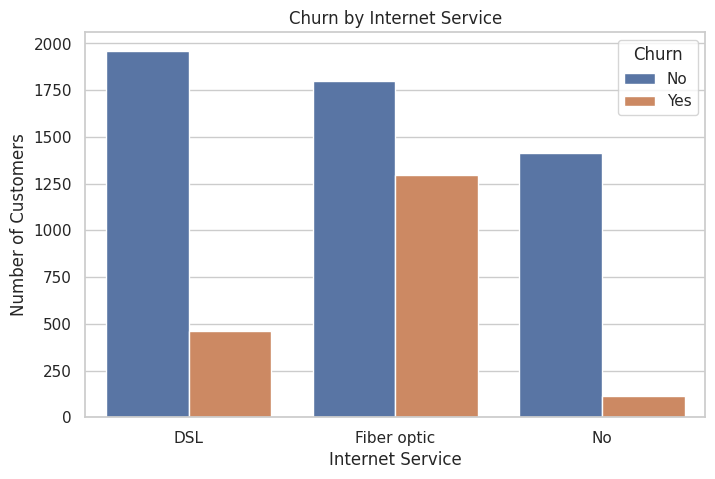

In [11]:
# Churn by internet service
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="InternetService", hue="Churn")
plt.title("Churn by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.show()


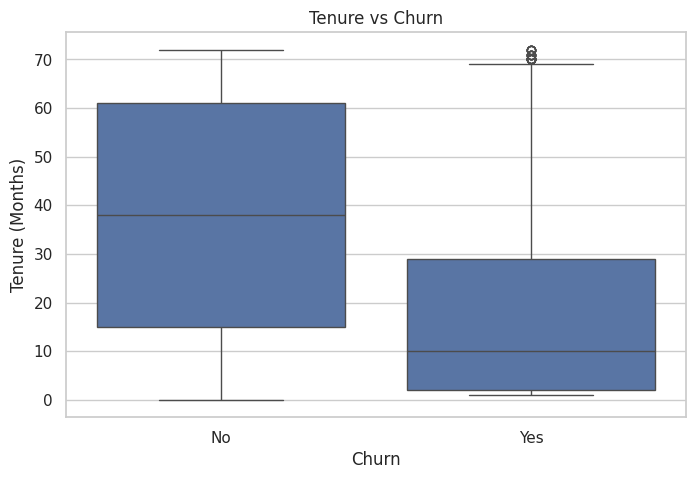

In [12]:
# Tenure distribution by churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="tenure")
plt.title("Tenure vs Churn")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")
plt.show()


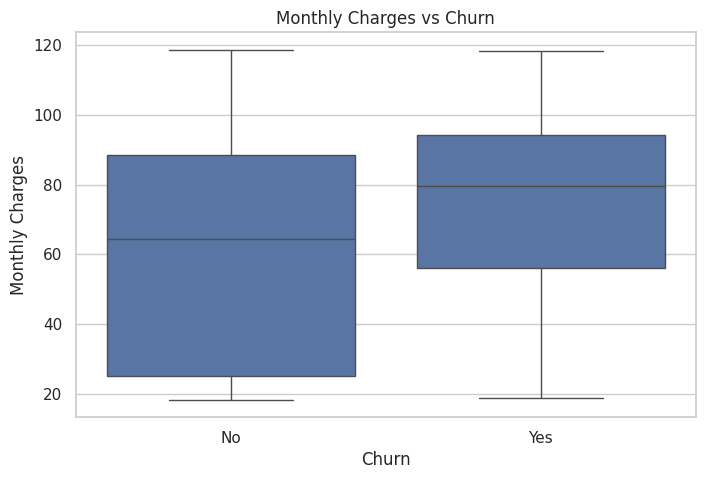

In [13]:
# Monthly charges by churn
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()


## 4. Feature Engineering and Encoding

In [14]:
# Separate input features (X) and target (y)
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"No": 0, "Yes": 1})

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget mapping: No = 0, Yes = 1")
display(X.head())


X shape: (7043, 19)
y shape: (7043,)

Target mapping: No = 0, Yes = 1


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65


In [15]:
# Identify numerical and categorical columns
numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


### Preprocessing strategy

- Numerical columns are filled using the median and standardized.
- Categorical columns are filled using the most frequent value and converted into numerical form using One-Hot Encoding.
- `customerID` is removed because it is an identifier and does not provide useful predictive information.


In [16]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessor created successfully.")


Preprocessor created successfully.


## 5. Training and Testing

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 5634
Testing samples: 1409


In [18]:
# Model 1: Logistic Regression
logistic_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])

# Model 2: Decision Tree
decision_tree_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(
        random_state=42,
        max_depth=5
    ))
])

logistic_model.fit(X_train, y_train)
decision_tree_model.fit(X_train, y_train)

print("Both models trained successfully.")


Both models trained successfully.


## 6. Model Evaluation

In [19]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    }

    print(f"\n===== {model_name} =====")
    print("Accuracy :", round(results["Accuracy"], 4))
    print("Precision:", round(results["Precision"], 4))
    print("Recall   :", round(results["Recall"], 4))
    print("F1-Score :", round(results["F1-Score"], 4))

    print("\nClassification Report:")
    print(classification_report(
        y_test, y_pred,
        target_names=["No Churn", "Churn"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    print("Confusion Matrix:")
    print(cm)

    return results, y_pred, cm


logistic_results, logistic_pred, logistic_cm = evaluate_model(
    logistic_model, X_test, y_test, "Logistic Regression"
)

tree_results, tree_pred, tree_cm = evaluate_model(
    decision_tree_model, X_test, y_test, "Decision Tree"
)



===== Logistic Regression =====
Accuracy : 0.8055
Precision: 0.6572
Recall   : 0.5588
F1-Score : 0.604

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409

Confusion Matrix:
[[926 109]
 [165 209]]

===== Decision Tree =====
Accuracy : 0.7984
Precision: 0.6347
Recall   : 0.5668
F1-Score : 0.5989

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.85      0.88      0.87      1035
       Churn       0.63      0.57      0.60       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409

Confusion Matrix:
[[913 122]
 [162 212]]


In [20]:
# Compare the models
comparison = pd.DataFrame([logistic_results, tree_results])
display(comparison)

best_model_name = comparison.loc[comparison["F1-Score"].idxmax(), "Model"]

if best_model_name == "Logistic Regression":
    final_model = logistic_model
else:
    final_model = decision_tree_model

print("Selected final model based on F1-Score:", best_model_name)


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.805536,0.657233,0.558824,0.604046
1,Decision Tree,0.798439,0.634731,0.566845,0.598870


Selected final model based on F1-Score: Logistic Regression


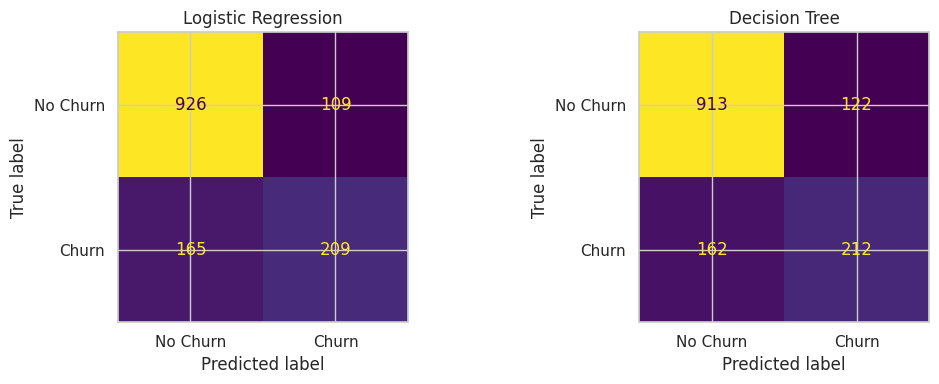

In [21]:
# Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["No Churn", "Churn"]
).plot(ax=axes[0], values_format="d", colorbar=False)
axes[0].set_title("Logistic Regression")

ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["No Churn", "Churn"]
).plot(ax=axes[1], values_format="d", colorbar=False)
axes[1].set_title("Decision Tree")

plt.tight_layout()
plt.show()


## 7. Application / Prediction

In [22]:
sample_customer = X_test.iloc[[0]].copy()

print("Sample customer information:")
display(sample_customer)

prediction = final_model.predict(sample_customer)[0]

prediction_label = "Churn" if prediction == 1 else "No Churn"

print("Predicted result:", prediction_label)


Sample customer information:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
437,Male,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,Yes,Yes,Yes,Yes,Yes,Two year,Yes,Credit card (automatic),114.05,8468.2


Predicted result: No Churn


In [23]:
sample_input = X.iloc[[0]].copy()

prediction = final_model.predict(sample_input)[0]
prediction_label = "Churn" if prediction == 1 else "No Churn"

print("Input customer:")
display(sample_input)
print("Model prediction:", prediction_label)


Input customer:


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85


Model prediction: Churn
